In [2]:
import pandas as pd
import os
import glob

In [3]:
result = {}
for each in glob.glob(pathname='../images/*'):
    target = each.split('/')[-1]
    result[target] = glob.glob(pathname=os.path.abspath(f'{each}/*.jpg'))

In [4]:
count = {}
for key in result.keys():
    count[key] = len(result[key])
    
counts = pd.DataFrame([count]).T

<Axes: >

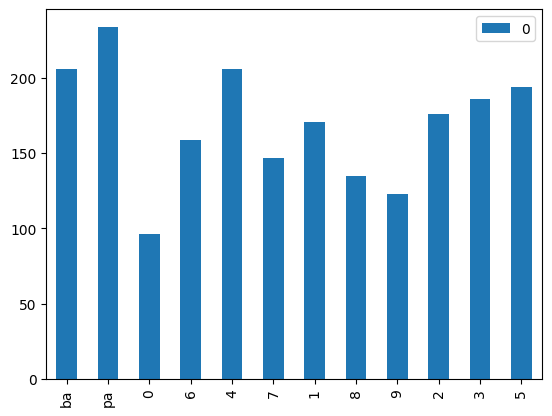

In [5]:
counts.plot(kind='bar')

---

## Lets work on Augumentation

In [6]:
import torch
import torchvision.transforms as transforms
from torchvision.utils import save_image
from PIL import Image
from matplotlib import pyplot as plt

# im = Image.open("sample-image.png")

torch.manual_seed(17)


In [7]:
# This function will read the image using its path with opencv
def Load_Image(Path):
    img = Image.open(Path)
    return img

def Show_Image(Image, Picture_Name='picture'):
    plt.imshow(Image)
    plt.title(Picture_Name)
    plt.show()

In [8]:
image1 = Load_Image(result['ba'][0])

In [9]:
image1.show()

There are several transformation techniques used for augmentation in OCR (Optical Character Recognition) applications. Some of the most commonly used techniques include:

Rotation: This involves rotating the image to a certain degree, which can help the OCR algorithm to recognize characters that may be tilted or skewed.

Scaling: This technique involves increasing or decreasing the size of the image. Scaling can be useful when working with images that have characters of varying sizes.

Translation: This involves shifting the image horizontally or vertically. Translation can help the OCR algorithm to recognize characters that may be slightly off-center.

Shearing: This technique involves skewing the image horizontally or vertically. Shearing can help the OCR algorithm to recognize characters that may be slanted.

Noise addition: This involves adding random noise to the image, which can help the OCR algorithm to be more robust to noisy environments and low-quality images.

Contrast adjustment: This technique involves adjusting the contrast of the image, which can help the OCR algorithm to recognize characters that may be too light or too dark.

These techniques can be used individually or in combination to create a large number of variations of the same image, which can help to improve the accuracy and robustness of the OCR algorithm.

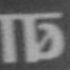

In [12]:
Horizontal_Flipping_Transformation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),
    transforms.CenterCrop(70),
])
hr_flip_image = Horizontal_Flipping_Transformation(image1)

transforms.functional.to_grayscale(hr_flip_image)